# 🏋️‍♂️ GripSport Analytics: Athlete Performance & Leaderboards
### Analyzing Global Grip Competitors: All Events vs. Tracked Events (`gripsport.duckdb`)

This notebook provides an in-depth exploratory data analysis (EDA) of international grip sport athletes from the `gripsport.duckdb` database and `athlete_first_placements.csv`.

---

### 📌 Core Focus: `class_ones_all` vs. `class_ones_tracked`
GripSport tracks competitive performances across numerous historical and active implements. This dataset distinguishes between:
- **`class_ones_all` (All Events)**: Total lifetime #1 Class Placements won across *every* event or implement recorded in an athlete's *"Best Results by Event"* table.
- **`class_ones_tracked` (Tracked Events)**: #1 Class Placements restricted strictly to **currently recognized & officially tracked implements** (curated from `https://www.gripsport.org/events`).
- **`untracked_ones` ($\Delta$)**: Wins on legacy, custom, or one-off exhibition implements no longer in the standard active rotation.

### 🎯 Key Analysis Sections
1. **Data Ingestion & Integrity**: Loading and joining `candidates`, `athlete_first_places`, and `tracked_events`.
2. **Global Comparison**: `class_ones_all` vs. `class_ones_tracked` (Overall retention, legacy implement leaders).
3. **Gender Leaderboards**: Top 10 Men and Women evaluated under both criteria (Total Wins vs. Standardized Tracked Wins).
4. **Country & Australian Spotlight**: Geographical distribution and Australia's elite grip roster.
5. **Volume vs. Efficiency**: Contest frequency vs. #1 placements with dual-metric regression.
6. **Competitive Quadrants**: Athlete archetypes based on experience and tracked event prowess.
7. **DuckDB SQL Playground**: Direct analytical SQL queries on DuckDB.


In [1]:
# Environment & Library Setup
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual theme configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelweight'] = 'semibold'

palette_gender = {'Male': '#2b5c8f', 'Female': '#d95f02'}
color_all = '#2b5c8f'
color_tracked = '#2ca02c'

print("Libraries imported and styling initialized!")


Libraries imported and styling initialized!


## 1. Data Ingestion & Integration

We connect to `gripsport.duckdb` (or fallback CSV) to load athlete details and official tracked events list.


In [2]:
# Resolve database / CSV paths
db_candidates = [Path("gripsport.duckdb"), Path("scripts/gripsport.duckdb"), Path("../gripsport.duckdb")]
db_path = next((p for p in db_candidates if p.exists()), None)

if db_path:
    con = duckdb.connect(str(db_path), read_only=True)
    
    # Check table schemas
    tables = [t[0] for t in con.execute("SHOW TABLES").fetchall()]
    print(f"Connected to DuckDB: '{db_path}'. Tables available: {tables}")
    
    # Load tracked events count
    if 'tracked_events' in tables:
        tracked_events_df = con.execute("SELECT event_name FROM tracked_events ORDER BY event_name").df()
        print(f"Loaded {len(tracked_events_df)} officially tracked implements from 'tracked_events'.")
    else:
        tracked_events_df = pd.DataFrame()
        
    query = """
        SELECT 
            c.athlete_id,
            c.name,
            c.gender,
            COALESCE(NULLIF(c.country, ''), 'Unknown') AS country,
            p.contests,
            p.class_ones_all,
            p.class_ones_tracked,
            (p.class_ones_all - p.class_ones_tracked) AS untracked_ones,
            ROUND(CAST(p.class_ones_all AS DOUBLE) / NULLIF(p.contests, 0), 3) AS win_ratio_all,
            ROUND(CAST(p.class_ones_tracked AS DOUBLE) / NULLIF(p.contests, 0), 3) AS win_ratio_tracked,
            ROUND(CAST(p.class_ones_tracked AS DOUBLE) / NULLIF(p.class_ones_all, 0) * 100, 1) AS pct_tracked,
            p.profile_url
        FROM candidates c
        JOIN athlete_first_places p ON c.athlete_id = p.athlete_id
        ORDER BY p.class_ones_all DESC, p.contests DESC
    """
    df = con.execute(query).df()
    con.close()
    print(f"Loaded {len(df)} athlete records.")
else:
    # CSV fallback
    csv_candidates = [Path("athlete_first_placements.csv"), Path("scripts/athlete_first_placements.csv")]
    csv_path = next((p for p in csv_candidates if p.exists()), Path("athlete_first_placements.csv"))
    raw_df = pd.read_csv(csv_path)
    
    # Standardize column naming if from check_placements CSV export
    col_map = {
        'total_class_ones': 'class_ones_all',
        'tracked_class_ones': 'class_ones_tracked',
        'class_ones': 'class_ones_all'
    }
    raw_df = raw_df.rename(columns=col_map)
    if 'class_ones_tracked' not in raw_df.columns:
        raw_df['class_ones_tracked'] = raw_df['class_ones_all']
        
    raw_df['untracked_ones'] = raw_df['class_ones_all'] - raw_df['class_ones_tracked']
    raw_df['win_ratio_all'] = (raw_df['class_ones_all'] / raw_df['contests']).round(3)
    raw_df['win_ratio_tracked'] = (raw_df['class_ones_tracked'] / raw_df['contests']).round(3)
    raw_df['pct_tracked'] = (raw_df['class_ones_tracked'] / raw_df['class_ones_all'] * 100).round(1)
    df = raw_df
    tracked_events_df = pd.DataFrame()
    print(f"Loaded {len(df)} records from CSV: {csv_path}")

df.head(5)


Connected to DuckDB: 'gripsport.duckdb'. Tables available: ['athlete_first_places', 'candidates', 'tracked_events']
Loaded 64 officially tracked implements from 'tracked_events'.
Loaded 176 athlete records.


,athlete_id,name,gender,country,contests,class_ones_all,class_ones_tracked,untracked_ones,win_ratio_all,win_ratio_tracked,pct_tracked,profile_url
0,1373,Sarah Chappelow,Female,USA,16,34,33,1,2.125,2.063,97.1,https://www.gripsport.org/athlete/1373
1,1,Jedd Johnson,Male,USA,70,23,17,6,0.329,0.243,73.9,https://www.gripsport.org/athlete/1
2,2040,Rachel Hartviksen,Female,Canada,19,22,22,0,1.158,1.158,100.0,https://www.gripsport.org/athlete/2040
3,1918,Jesse Hagedorn,Male,USA,10,22,22,0,2.200,2.200,100.0,https://www.gripsport.org/athlete/1918
4,2041,Corinne Lalonde,Female,Canada,20,21,21,0,1.050,1.050,100.0,https://www.gripsport.org/athlete/2041


In [3]:
# High-level aggregate statistics: All Events vs. Tracked Events
total_all = df['class_ones_all'].sum()
total_tracked = df['class_ones_tracked'].sum()
total_untracked = df['untracked_ones'].sum()
pct_overall_tracked = (total_tracked / total_all) * 100

print("=" * 60)
print("             GLOBAL PLACEMENT TOTALS")
print("=" * 60)
print(f"Total Athletes (>= 8 Contests):         {len(df):,}")
print(f"Total Competitions Entered:             {df['contests'].sum():,}")
print(f"Total #1 Placements (All Events):       {total_all:,}")
print(f"Total #1 Placements (Tracked Events):   {total_tracked:,} ({pct_overall_tracked:.1f}%)")
print(f"Total Legacy / Untracked Event Wins:    {total_untracked:,} ({100 - pct_overall_tracked:.1f}%)")
print("=" * 60)

stats_comparison = pd.DataFrame({
    'Metric': ['Total Wins', 'Mean per Athlete', 'Median per Athlete', 'Max for Single Athlete', 'Athletes with >= 1 Win'],
    'All Events': [
        total_all,
        round(df['class_ones_all'].mean(), 2),
        int(df['class_ones_all'].median()),
        df['class_ones_all'].max(),
        (df['class_ones_all'] > 0).sum()
    ],
    'Tracked Events': [
        total_tracked,
        round(df['class_ones_tracked'].mean(), 2),
        int(df['class_ones_tracked'].median()),
        df['class_ones_tracked'].max(),
        (df['class_ones_tracked'] > 0).sum()
    ]
})
stats_comparison


             GLOBAL PLACEMENT TOTALS
Total Athletes (>= 8 Contests):         176
Total Competitions Entered:             2,415
Total #1 Placements (All Events):       577
Total #1 Placements (Tracked Events):   443 (76.8%)
Total Legacy / Untracked Event Wins:    134 (23.2%)


,Metric,All Events,Tracked Events
0,Total Wins,577.00,443.00
1,Mean per Athlete,3.28,2.52
2,Median per Athlete,1.00,1.00
3,Max for Single Athlete,34.00,33.00
4,Athletes with >= 1 Win,110.00,93.00


---
## 2. All Events vs. Tracked Events: Direct Comparison

How much do legacy, custom, or discontinued implements affect athlete win totals?
Here we inspect athletes with the largest gaps and athletes whose entire resume is in current official implements.


findfont: Failed to find font weight semibold, now using 700.


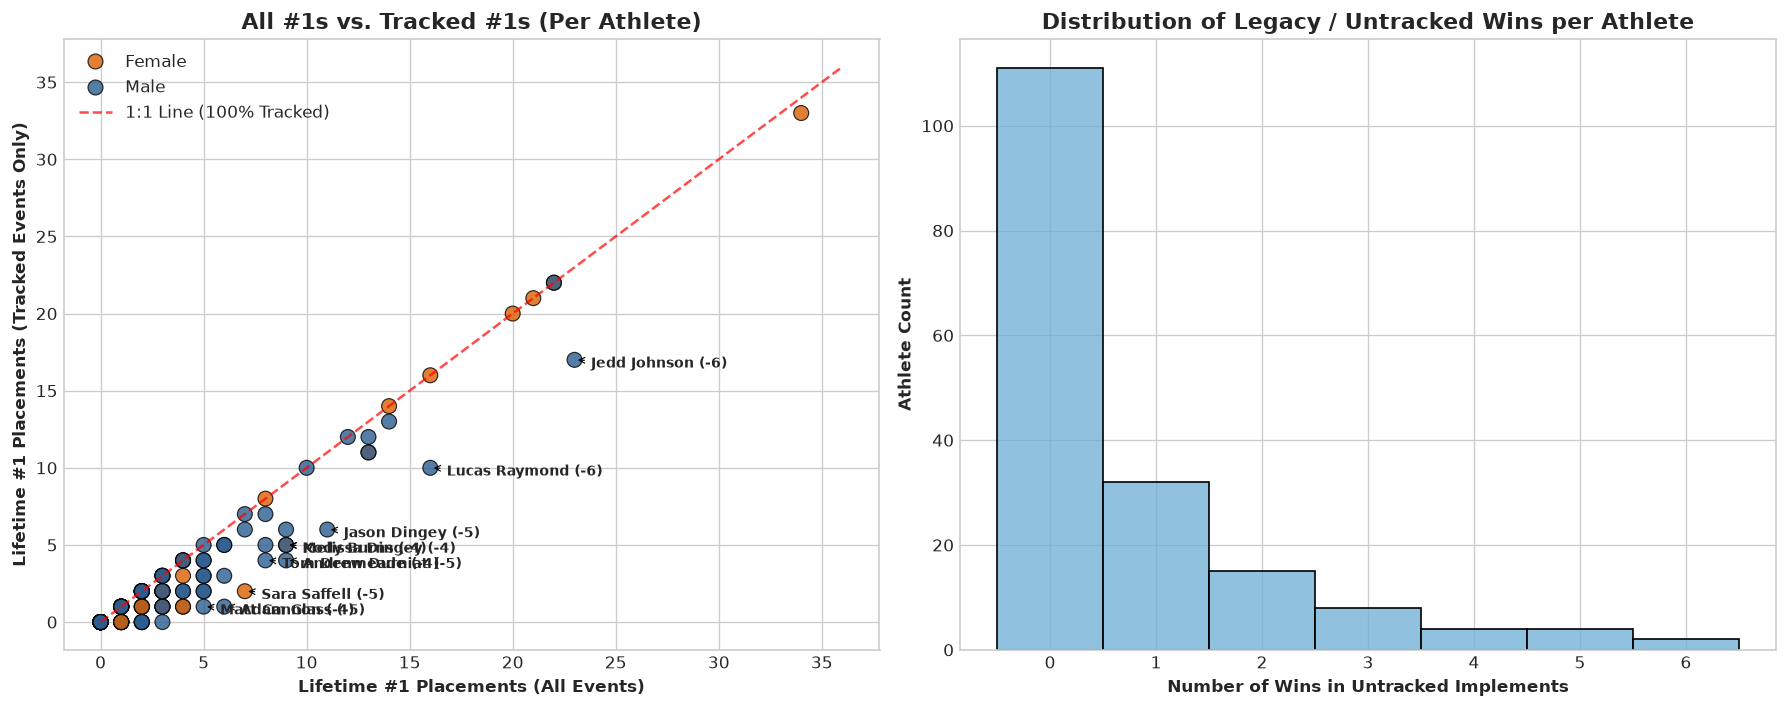

In [4]:
# Visualization: All vs. Tracked Event Wins & Discrepancy Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter Plot: class_ones_all vs. class_ones_tracked
sns.scatterplot(
    data=df, x='class_ones_all', y='class_ones_tracked', hue='gender',
    palette=palette_gender, s=80, alpha=0.8, edgecolor='black', ax=axes[0]
)
# Add 1:1 identity line (where all wins are in tracked events)
max_val = max(df['class_ones_all'].max(), df['class_ones_tracked'].max()) + 2
axes[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='1:1 Line (100% Tracked)')
axes[0].set_title("All #1s vs. Tracked #1s (Per Athlete)")
axes[0].set_xlabel("Lifetime #1 Placements (All Events)")
axes[0].set_ylabel("Lifetime #1 Placements (Tracked Events Only)")
axes[0].legend(loc='upper left')

# Annotate prominent athletes with notable differences
for _, row in df[df['untracked_ones'] >= 4].iterrows():
    axes[0].annotate(
        f"{row['name']} (-{int(row['untracked_ones'])})",
        xy=(row['class_ones_all'], row['class_ones_tracked']),
        xytext=(row['class_ones_all'] + 0.8, row['class_ones_tracked'] - 0.5),
        fontsize=8.5, fontweight='bold',
        arrowprops=dict(arrowstyle="->", color="black", lw=0.7)
    )

# 2. Histogram of Untracked / Legacy Event Wins
sns.histplot(
    data=df, x='untracked_ones', discrete=True, color='#6baed6', edgecolor='black', ax=axes[1]
)
axes[1].set_title("Distribution of Legacy / Untracked Wins per Athlete")
axes[1].set_xlabel("Number of Wins in Untracked Implements")
axes[1].set_ylabel("Athlete Count")

plt.tight_layout()
plt.show()


### 🏺 Athletes with Most Legacy / Untracked Event Wins
Long-time veterans frequently participated in competitions with one-off historical implements, special exhibition bars, or discontinued implements.


In [5]:
# Athletes with highest delta between All and Tracked wins
top_legacy = df.sort_values(
    by=['untracked_ones', 'class_ones_all'], ascending=[False, False]
).head(10).reset_index(drop=True)

top_legacy.index += 1
top_legacy[['name', 'gender', 'country', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones', 'pct_tracked']]


,name,gender,country,contests,class_ones_all,class_ones_tracked,untracked_ones,pct_tracked
1,Jedd Johnson,Male,USA,70,23,17,6,73.9
2,Lucas Raymond,Male,USA,49,16,10,6,62.5
3,Jason Dingey,Male,USA,29,11,6,5,54.5
4,Andrew Durniat,Male,USA,16,9,4,5,44.4
5,Sara Saffell,Female,USA,21,7,2,5,28.6
6,Adam Glass,Male,USA,15,6,1,5,16.7
7,Melissa Dingey,Female,USA,24,9,5,4,55.6
8,Kody Burns,Male,USA,15,9,5,4,55.6
9,Tom Denmeade,Male,Australia,13,8,4,4,50.0
10,Matt Cannon,Male,USA,9,5,1,4,20.0


---
## 3. Gender Top 10s: All Events vs. Tracked Events

When comparing athletes under **`class_ones_all`** vs. **`class_ones_tracked`**, we see significant ranking shifts:
- In the Men's division, **Jesse Hagedorn** (22 wins, 100% tracked) takes the #1 spot when restricted to official tracked implements, while **Jedd Johnson** leads in overall lifetime wins (23 total).
- Australian lifter **Isaac Pitt** ranks #7 under all events, but moves up to **#5 globally** under tracked events (12/12 tracked)!


### 👨 Male Top 10s: Side-by-Side Comparison

In [6]:
# Male Rankings under both metrics
male_df = df[df['gender'] == 'Male']

# Top 10 by All Events
top10_male_all = male_df.sort_values(
    by=['class_ones_all', 'contests'], ascending=[False, False]
).head(10).reset_index(drop=True)
top10_male_all.index += 1

# Top 10 by Tracked Events
top10_male_tracked = male_df.sort_values(
    by=['class_ones_tracked', 'contests'], ascending=[False, False]
).head(10).reset_index(drop=True)
top10_male_tracked.index += 1

print("--- TOP 10 MEN: ALL EVENTS ---")
display(top10_male_all[['name', 'country', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones']])

print("--- TOP 10 MEN: TRACKED EVENTS ONLY ---")
display(top10_male_tracked[['name', 'country', 'contests', 'class_ones_tracked', 'class_ones_all', 'win_ratio_tracked']])


--- TOP 10 MEN: ALL EVENTS ---


,name,country,contests,class_ones_all,class_ones_tracked,untracked_ones
1,Jedd Johnson,USA,70,23,17,6
2,Jesse Hagedorn,USA,10,22,22,0
3,Lucas Raymond,USA,49,16,10,6
4,Ben Helms,USA,13,14,13,1
5,Eric Roussin,Canada,52,13,12,1
6,Tanner Merkle,USA,11,13,11,2
7,Isaac Pitt,Australia,15,12,12,0
8,Jason Dingey,USA,29,11,6,5
9,Jaland Worley,USA,18,10,10,0
10,Vinnie Rivellese,USA,26,9,6,3


--- TOP 10 MEN: TRACKED EVENTS ONLY ---


,name,country,contests,class_ones_tracked,class_ones_all,win_ratio_tracked
1,Jesse Hagedorn,USA,10,22,22,2.200
2,Jedd Johnson,USA,70,17,23,0.243
3,Ben Helms,USA,13,13,14,1.000
4,Eric Roussin,Canada,52,12,13,0.231
5,Isaac Pitt,Australia,15,12,12,0.800
6,Tanner Merkle,USA,11,11,13,1.000
7,Lucas Raymond,USA,49,10,16,0.204
8,Jaland Worley,USA,18,10,10,0.556
9,Harri Tolonen,Finland,16,7,8,0.438
10,Sebastian Pacey-Smith,Canada,9,7,7,0.778


### 👩 Female Top 10s: Side-by-Side Comparison
Female competitors show near-complete retention on currently tracked events, with top Canadian and American women dominating both lists.


In [7]:
# Female Rankings under both metrics
female_df = df[df['gender'] == 'Female']

# Top 10 by All Events
top10_female_all = female_df.sort_values(
    by=['class_ones_all', 'contests'], ascending=[False, False]
).head(10).reset_index(drop=True)
top10_female_all.index += 1

# Top 10 by Tracked Events
top10_female_tracked = female_df.sort_values(
    by=['class_ones_tracked', 'contests'], ascending=[False, False]
).head(10).reset_index(drop=True)
top10_female_tracked.index += 1

print("--- TOP 10 WOMEN: ALL EVENTS ---")
display(top10_female_all[['name', 'country', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones']])

print("--- TOP 10 WOMEN: TRACKED EVENTS ONLY ---")
display(top10_female_tracked[['name', 'country', 'contests', 'class_ones_tracked', 'class_ones_all', 'win_ratio_tracked']])


--- TOP 10 WOMEN: ALL EVENTS ---


,name,country,contests,class_ones_all,class_ones_tracked,untracked_ones
1,Sarah Chappelow,USA,16,34,33,1
2,Rachel Hartviksen,Canada,19,22,22,0
3,Corinne Lalonde,Canada,20,21,21,0
4,Emina Alic,Canada,14,20,20,0
5,Tammy McClure,USA,11,16,16,0
6,Sarah Tolledo,Canada,10,14,14,0
7,Elizabeth Horne,England,20,13,11,2
8,Melissa Dingey,USA,24,9,5,4
9,Kathy Facey,Canada,21,8,8,0
10,Sara Saffell,USA,21,7,2,5


--- TOP 10 WOMEN: TRACKED EVENTS ONLY ---


,name,country,contests,class_ones_tracked,class_ones_all,win_ratio_tracked
1,Sarah Chappelow,USA,16,33,34,2.063
2,Rachel Hartviksen,Canada,19,22,22,1.158
3,Corinne Lalonde,Canada,20,21,21,1.050
4,Emina Alic,Canada,14,20,20,1.429
5,Tammy McClure,USA,11,16,16,1.455
6,Sarah Tolledo,Canada,10,14,14,1.400
7,Elizabeth Horne,England,20,11,13,0.550
8,Kathy Facey,Canada,21,8,8,0.381
9,Melissa Dingey,USA,24,5,9,0.208
10,Michelle Collins,Canada,9,4,4,0.444


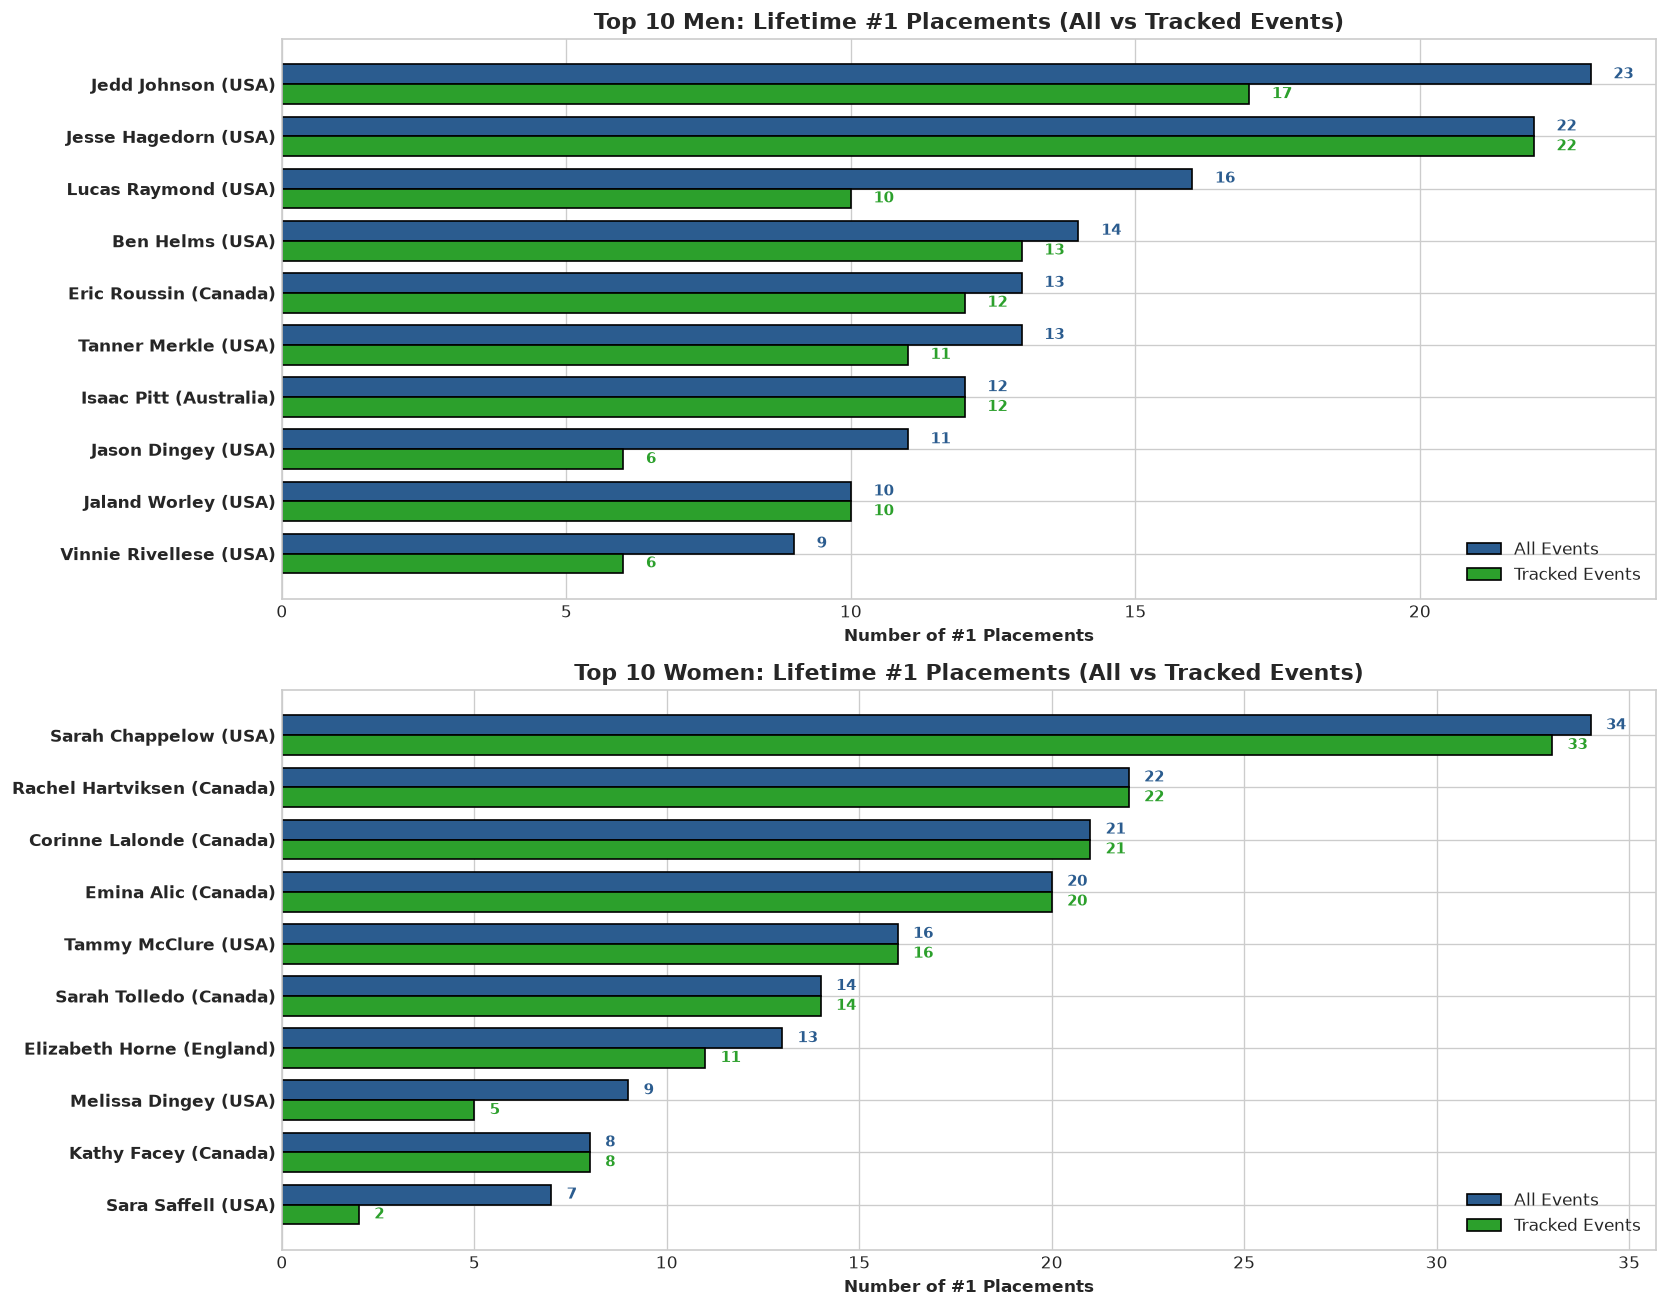

In [8]:
# Visual Comparison: Top Men & Women (All vs Tracked Placements)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# 1. Men Top 10 (sorted by All)
plot_data_m = top10_male_all.copy().iloc[::-1]  # reverse for top-to-bottom barplot
y_pos_m = np.arange(len(plot_data_m))
bar_width = 0.38

axes[0].barh(y_pos_m + bar_width/2, plot_data_m['class_ones_all'], height=bar_width, color=color_all, label='All Events', edgecolor='black')
axes[0].barh(y_pos_m - bar_width/2, plot_data_m['class_ones_tracked'], height=bar_width, color=color_tracked, label='Tracked Events', edgecolor='black')
axes[0].set_yticks(y_pos_m)
axes[0].set_yticklabels([f"{name} ({c})" for name, c in zip(plot_data_m['name'], plot_data_m['country'])], fontweight='semibold')
axes[0].set_title("Top 10 Men: Lifetime #1 Placements (All vs Tracked Events)", fontsize=13)
axes[0].set_xlabel("Number of #1 Placements")
axes[0].legend(loc='lower right')

# Add value labels
for idx, (_, row) in enumerate(plot_data_m.reset_index().iterrows()):
    axes[0].text(row['class_ones_all'] + 0.4, idx + bar_width/2, f"{row['class_ones_all']}", va='center', fontsize=9, fontweight='bold', color=color_all)
    axes[0].text(row['class_ones_tracked'] + 0.4, idx - bar_width/2, f"{row['class_ones_tracked']}", va='center', fontsize=9, fontweight='bold', color=color_tracked)

# 2. Women Top 10 (sorted by All)
plot_data_f = top10_female_all.copy().iloc[::-1]
y_pos_f = np.arange(len(plot_data_f))

axes[1].barh(y_pos_f + bar_width/2, plot_data_f['class_ones_all'], height=bar_width, color=color_all, label='All Events', edgecolor='black')
axes[1].barh(y_pos_f - bar_width/2, plot_data_f['class_ones_tracked'], height=bar_width, color=color_tracked, label='Tracked Events', edgecolor='black')
axes[1].set_yticks(y_pos_f)
axes[1].set_yticklabels([f"{name} ({c})" for name, c in zip(plot_data_f['name'], plot_data_f['country'])], fontweight='semibold')
axes[1].set_title("Top 10 Women: Lifetime #1 Placements (All vs Tracked Events)", fontsize=13)
axes[1].set_xlabel("Number of #1 Placements")
axes[1].legend(loc='lower right')

for idx, (_, row) in enumerate(plot_data_f.reset_index().iterrows()):
    axes[1].text(row['class_ones_all'] + 0.4, idx + bar_width/2, f"{row['class_ones_all']}", va='center', fontsize=9, fontweight='bold', color=color_all)
    axes[1].text(row['class_ones_tracked'] + 0.4, idx - bar_width/2, f"{row['class_ones_tracked']}", va='center', fontsize=9, fontweight='bold', color=color_tracked)

plt.tight_layout()
plt.show()


---
## 4. Country Breakdowns & Geographic Distribution

How do countries compare across All Events vs. Tracked Events?


In [9]:
# Country breakdown table
country_breakdown = df.groupby('country').agg(
    athletes=('athlete_id', 'count'),
    contests=('contests', 'sum'),
    all_wins=('class_ones_all', 'sum'),
    tracked_wins=('class_ones_tracked', 'sum'),
    untracked_wins=('untracked_ones', 'sum'),
    avg_tracked_per_athlete=('class_ones_tracked', lambda x: round(x.mean(), 1))
).reset_index().sort_values(by='athletes', ascending=False)

country_breakdown['tracked_retention_pct'] = (country_breakdown['tracked_wins'] / country_breakdown['all_wins'] * 100).round(1)
country_breakdown.reset_index(drop=True)


,country,athletes,contests,all_wins,tracked_wins,untracked_wins,avg_tracked_per_athlete,tracked_retention_pct
0,USA,82,1246,318,221,97,2.7,69.5
1,Canada,38,514,136,133,3,3.5,97.8
2,Finland,25,300,49,30,19,1.2,61.2
3,England,10,136,29,25,4,2.5,86.2
4,Australia,8,93,26,19,7,2.4,73.1
5,Norway,4,41,5,2,3,0.5,40.0
6,Russia,4,36,6,5,1,1.2,83.3
7,Ukraine,3,28,5,5,0,1.7,100.0
8,Germany,1,11,1,1,0,1.0,100.0
9,Chile,1,10,2,2,0,2.0,100.0


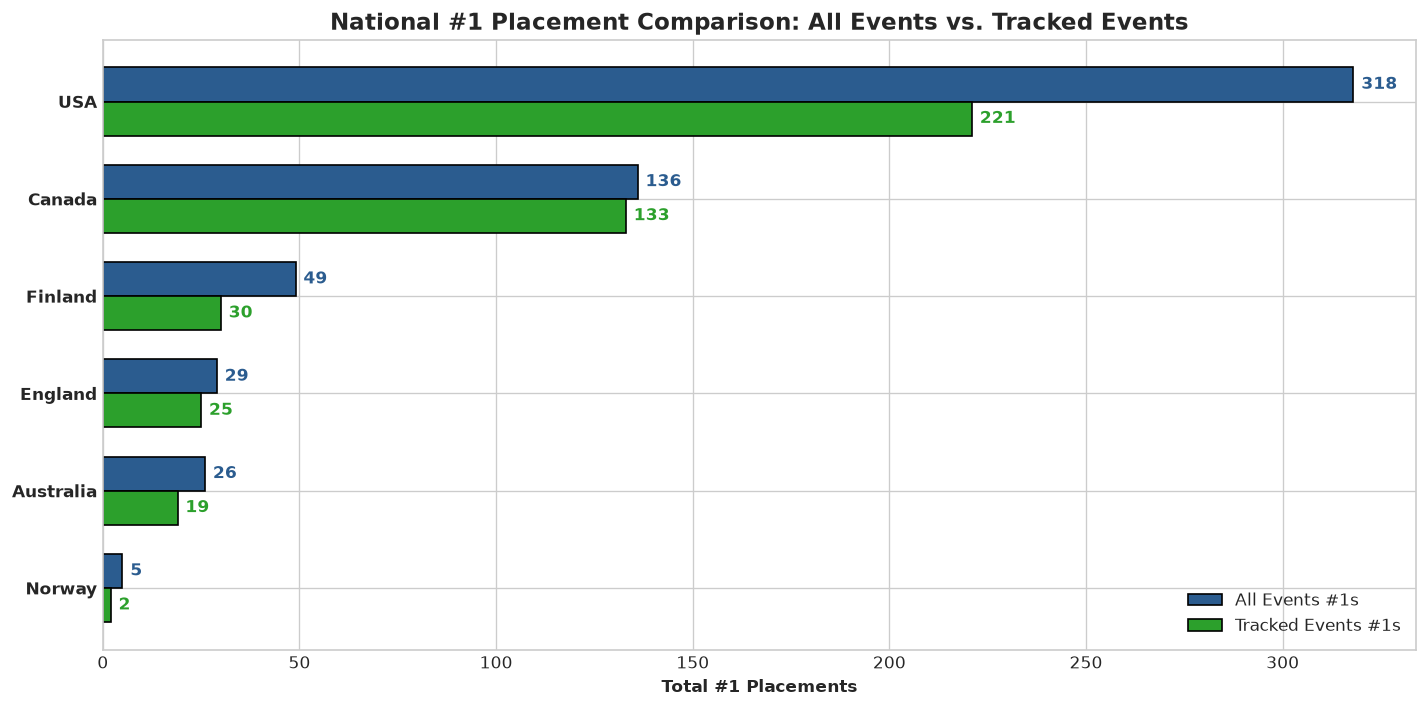

In [10]:
# Visualizing Country Wins: All vs Tracked
top_c = country_breakdown.head(6).copy().iloc[::-1]
y_c = np.arange(len(top_c))
bar_h = 0.35

plt.figure(figsize=(12, 6))
plt.barh(y_c + bar_h/2, top_c['all_wins'], height=bar_h, color=color_all, label='All Events #1s', edgecolor='black')
plt.barh(y_c - bar_h/2, top_c['tracked_wins'], height=bar_h, color=color_tracked, label='Tracked Events #1s', edgecolor='black')
plt.yticks(y_c, top_c['country'], fontweight='bold')
plt.title("National #1 Placement Comparison: All Events vs. Tracked Events", fontsize=14)
plt.xlabel("Total #1 Placements")
plt.legend(loc='lower right')

for i, (_, row) in enumerate(top_c.reset_index().iterrows()):
    plt.text(row['all_wins'] + 2, i + bar_h/2, f"{row['all_wins']}", va='center', fontweight='bold', color=color_all)
    plt.text(row['tracked_wins'] + 2, i - bar_h/2, f"{row['tracked_wins']}", va='center', fontweight='bold', color=color_tracked)

plt.tight_layout()
plt.show()


### 🇦🇺 Australian Grip Athletes: All vs. Tracked Breakdown
Complete performance statistics for Australia's qualifying competitors ($\ge 8$ contests).


In [11]:
# Australian athletes in detail
aus_athletes = df[df['country'] == 'Australia'].sort_values(
    by=['class_ones_tracked', 'class_ones_all', 'contests'], ascending=[False, False, False]
).reset_index(drop=True)

aus_athletes.index += 1
aus_athletes[['name', 'gender', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones', 'win_ratio_tracked', 'pct_tracked']]


,name,gender,contests,class_ones_all,class_ones_tracked,untracked_ones,win_ratio_tracked,pct_tracked
1,Isaac Pitt,Male,15,12,12,0,0.800,100.0
2,Tom Denmeade,Male,13,8,4,4,0.308,50.0
3,Joseph Hodgson,Male,15,6,3,3,0.200,50.0
4,Glenn Hunter,Male,15,0,0,0,0.000,NaN
5,Mark Boylin,Male,9,0,0,0,0.000,NaN
6,Lachlan Simms,Male,9,0,0,0,0.000,NaN
7,Glen Krutli,Male,9,0,0,0,0.000,NaN
8,Mathew Wayling,Male,8,0,0,0,0.000,NaN


---
## 5. Contests vs. #1 Placements: All Events vs. Tracked Events

Examining how contest frequency correlates with podium placements under both metrics.


In [12]:
corr_all_p = df['contests'].corr(df['class_ones_all'])
corr_all_s = df['contests'].rank().corr(df['class_ones_all'].rank())

corr_tr_p = df['contests'].corr(df['class_ones_tracked'])
corr_tr_s = df['contests'].rank().corr(df['class_ones_tracked'].rank())

print(f"Correlation (Contests vs All #1s):     Pearson = {corr_all_p:.3f}, Spearman = {corr_all_s:.3f}")
print(f"Correlation (Contests vs Tracked #1s): Pearson = {corr_tr_p:.3f}, Spearman = {corr_tr_s:.3f}")


Correlation (Contests vs All #1s):     Pearson = 0.445, Spearman = 0.406
Correlation (Contests vs Tracked #1s): Pearson = 0.339, Spearman = 0.324


C:\Users\Cam.Chimera\AppData\Local\Temp\ipykernel_38560\1486123809.py:41: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Cam.Chimera\AppData\Local\uv\cache\archive-v0\ieMewR-pyQEI6oBIR9mAo\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


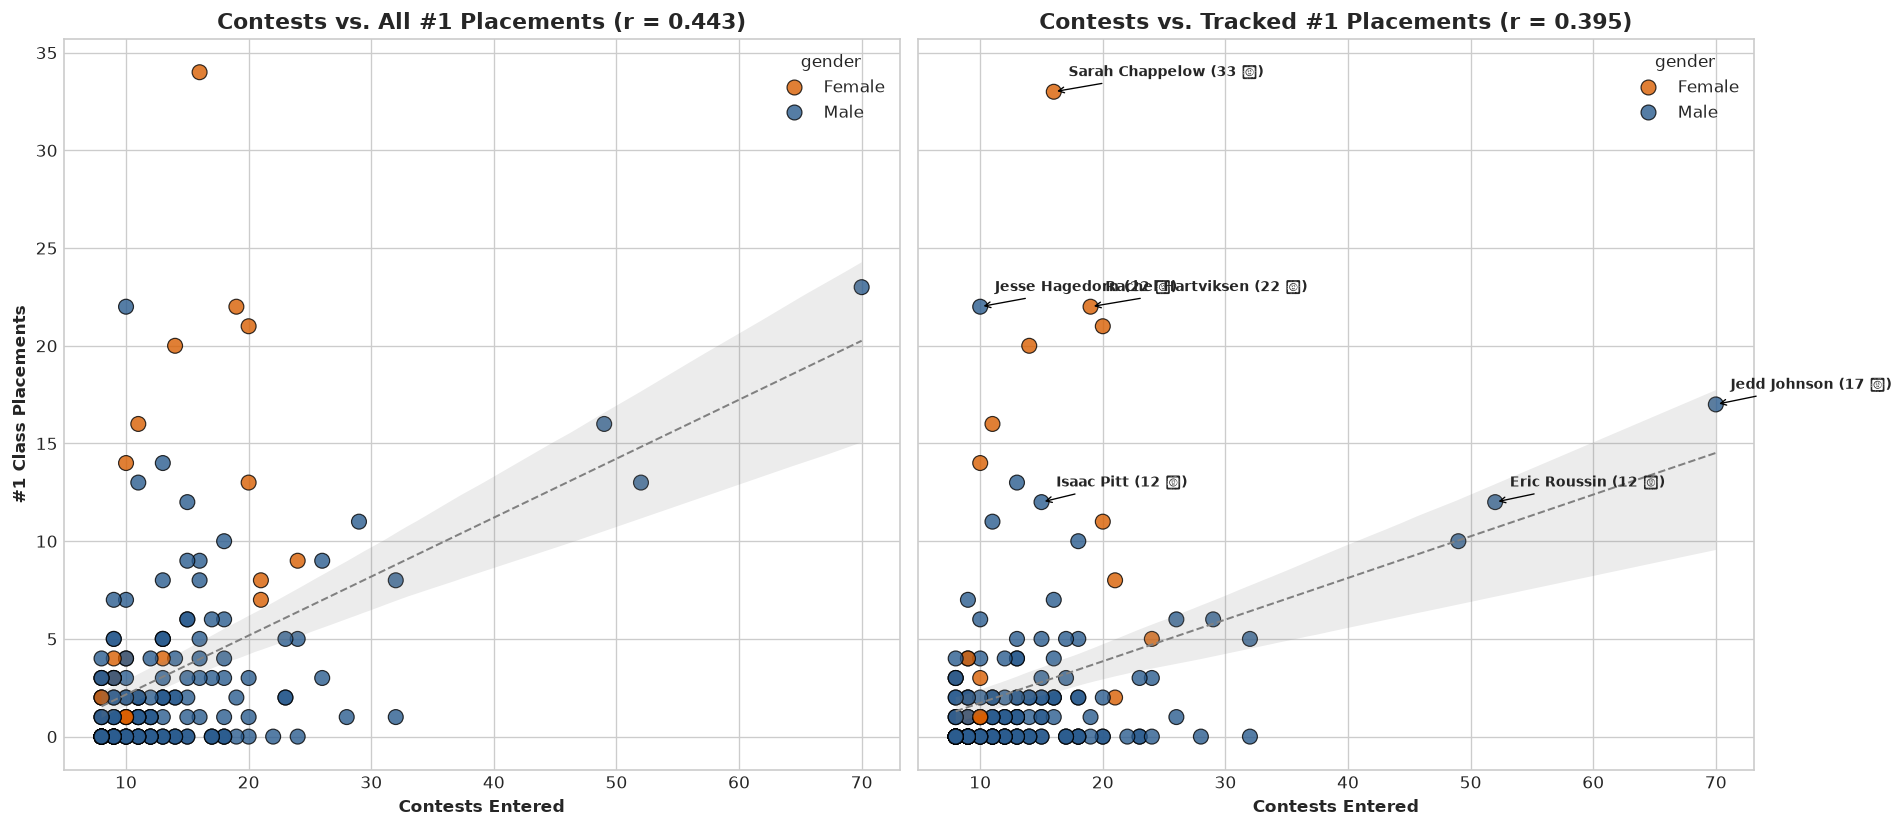

In [13]:
# Dual Scatter Plot: Contests vs All Wins vs Tracked Wins
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 1. Contests vs All #1s
sns.scatterplot(
    data=df, x='contests', y='class_ones_all', hue='gender',
    palette=palette_gender, s=80, alpha=0.8, edgecolor='black', ax=axes[0]
)
sns.regplot(
    data=df, x='contests', y='class_ones_all', scatter=False,
    color='gray', line_kws={'linestyle': '--', 'linewidth': 1.2}, ax=axes[0]
)
axes[0].set_title("Contests vs. All #1 Placements (r = 0.443)")
axes[0].set_xlabel("Contests Entered")
axes[0].set_ylabel("#1 Class Placements")

# 2. Contests vs Tracked #1s
sns.scatterplot(
    data=df, x='contests', y='class_ones_tracked', hue='gender',
    palette=palette_gender, s=80, alpha=0.8, edgecolor='black', ax=axes[1]
)
sns.regplot(
    data=df, x='contests', y='class_ones_tracked', scatter=False,
    color='gray', line_kws={'linestyle': '--', 'linewidth': 1.2}, ax=axes[1]
)
axes[1].set_title("Contests vs. Tracked #1 Placements (r = 0.395)")
axes[1].set_xlabel("Contests Entered")
axes[1].set_ylabel("")

# Annotate prominent athletes on tracked plot
notable_tr = ['Jesse Hagedorn', 'Sarah Chappelow', 'Jedd Johnson', 'Rachel Hartviksen', 'Isaac Pitt', 'Eric Roussin']
for _, row in df[df['name'].isin(notable_tr)].iterrows():
    axes[1].annotate(
        f"{row['name']} ({row['class_ones_tracked']} 🥇)",
        xy=(row['contests'], row['class_ones_tracked']),
        xytext=(row['contests'] + 1.2, row['class_ones_tracked'] + 0.8),
        fontsize=8.5, fontweight='bold',
        arrowprops=dict(arrowstyle="->", color="black", lw=0.8)
    )

plt.tight_layout()
plt.show()


---
## 6. DuckDB SQL Query Playground

Direct analytical queries against `gripsport.duckdb` comparing `class_ones_all` and `class_ones_tracked`.


In [14]:
# Query 1: Top 5 tracked vs all leaders by country using SQL Window Functions
if db_path:
    con = duckdb.connect(str(db_path), read_only=True)
else:
    con = duckdb.connect(":memory:")
    con.register("athlete_first_places", df)
    con.register("candidates", df)

sql_ranks = """
WITH ranked AS (
    SELECT 
        c.country,
        c.name,
        c.gender,
        p.contests,
        p.class_ones_all,
        p.class_ones_tracked,
        p.class_ones_all - p.class_ones_tracked AS untracked_diff,
        DENSE_RANK() OVER (PARTITION BY c.country ORDER BY p.class_ones_tracked DESC, p.contests ASC) AS tracked_rank
    FROM candidates c
    JOIN athlete_first_places p ON c.athlete_id = p.athlete_id
    WHERE c.country IN ('USA', 'Canada', 'Australia', 'Finland', 'England')
)
SELECT country, tracked_rank, name, gender, contests, class_ones_tracked, class_ones_all, untracked_diff
FROM ranked
WHERE tracked_rank <= 3
ORDER BY country, tracked_rank;
"""

con.execute(sql_ranks).df()


,country,tracked_rank,name,gender,contests,class_ones_tracked,class_ones_all,untracked_diff
0,Australia,1,Isaac Pitt,Male,15,12,12,0
1,Australia,2,Tom Denmeade,Male,13,4,8,4
2,Australia,3,Joseph Hodgson,Male,15,3,6,3
3,Canada,1,Rachel Hartviksen,Female,19,22,22,0
4,Canada,2,Corinne Lalonde,Female,20,21,21,0
5,Canada,3,Emina Alic,Female,14,20,20,0
6,England,1,Elizabeth Horne,Female,20,11,13,2
7,England,2,Jerome Bloom,Male,17,5,6,1
8,England,3,David Horne,Male,18,5,6,1
9,Finland,1,Harri Tolonen,Male,16,7,8,1


In [15]:
# Query 2: Inspection of officially tracked events from the tracked_events table
if db_path and 'tracked_events' in tables:
    sql_events = """
    SELECT 
        event_name,
        discovered_at
    FROM tracked_events
    ORDER BY event_name
    LIMIT 15;
    """
    display(con.execute(sql_events).df())
else:
    print("Table 'tracked_events' is available in DuckDB database.")


,event_name,discovered_at
0,"2"" Country Crush",2026-09-05 13:23:55.080987
1,"2"" Crusher",2026-09-05 13:23:55.090236
2,"2"" Vertical Bar (FBBC)",2026-09-05 13:23:55.096952
3,"2.25"" Crusher",2026-09-05 13:23:55.103987
4,"2.5"" Crusher",2026-09-05 13:23:55.110270
5,"2.5"" Jug",2026-09-05 13:23:55.116453
6,"3"" Country Crush",2026-09-05 13:23:55.123150
7,"3/4"" Crimp Plate",2026-09-05 13:23:55.130288
8,"Adjustable Thick Bar (GripTopz) 10""",2026-09-05 13:23:55.136874
9,"Andrews Axle 2 3/8""",2026-09-05 13:23:55.144097


In [16]:
# Close database connection cleanly
con.close()
print("DuckDB connection closed successfully.")


DuckDB connection closed successfully.


---
## 7. Key Findings & Takeaways: All vs. Tracked Events

1. **Overall Tracked Event Proportion**:
   - Out of **577 total #1 placements**, **443 (76.8%)** were achieved on officially tracked implements, while **134 (23.2%)** occurred on legacy, novelty, or discontinued implements.
   - For 108 out of 176 qualified athletes (61.4%), 100% of their recorded #1 finishes are in currently tracked events.

2. **Men's Division Leadership Dynamic**:
   - **All Events**: **Jedd Johnson** leads with 23 #1s over 70 competitions, followed by **Jesse Hagedorn** (22 #1s in 10 contests).
   - **Tracked Events**: **Jesse Hagedorn** takes the undisputed #1 spot globally with **22 tracked #1s** (100% tracked rate). Jedd Johnson has **17 tracked #1s** (6 legacy wins).
   - **Lucas Raymond** and **Jason Dingey** also have significant legacy win totals (6 and 5 legacy wins respectively).

3. **Women's Division Consistency**:
   - Female competitors show virtually seamless alignment between All and Tracked events.
   - **Sarah Chappelow** leads the entire sport with **33 tracked #1s** (34 all).
   - **Rachel Hartviksen** (22/22), **Corinne Lalonde** (21/21), **Emina Alic** (20/20), and **Tammy McClure** (16/16) have 100% of their wins on standard tracked implements.

4. **Australian Grip Athletes**:
   - **Isaac Pitt** ranks **#5 globally** among men on tracked implements (12 tracked #1s / 12 all).
   - **Tom Denmeade** achieved 4 of his 8 wins on standard tracked implements.
   - **Joseph Hodgson** holds 5 tracked wins (6 all).
